# Gamma PCA Statistical Factor Model

Clean implementation of the statistical factor model with optional idiosyncratic-volatility rescaling. Set `GAMMA = 0.0` for the no-idio model and `GAMMA = 1.0` for full idio-vol rescaling.

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
from scipy.sparse.linalg import svds
from tqdm import tqdm

pd.set_option("display.max_columns", 100)


In [17]:
# Configuration
RETURNS_PATH = "Data/daily_returns_SPX.h5"
OUTPUT_DIR = "Data/Statistical_loadings"

N_FACTORS = 10
WINDOW_CORR = 800
CORR_HALF_LIFE = 200
WINDOW_IDIO = 600
IDIO_HALF_LIFE = 150
N_IDIO_FACTORS = 10
TOTAL_RETURN_RESCALING = False
# 0.0 = no idio scaling, 1.0 = full idio scaling, values in between are partial scaling.
GAMMA = 1.0

START_T = WINDOW_CORR - 1
END_T = None  # None means returns.shape[0] - 1
SAVE_OUTPUTS = False


In [18]:
returns = pd.read_hdf(RETURNS_PATH)
returns = returns.apply(pd.to_numeric)
returns = returns.sort_index()

if END_T is None:
    END_T = returns.shape[0] - 1

assert START_T >= WINDOW_CORR - 1
assert END_T <= returns.shape[0] - 1
returns.shape, returns.index[START_T], returns.index[END_T]


((2514, 428),
 Timestamp('2019-05-13 00:00:00'),
 Timestamp('2026-03-09 00:00:00'))

## Helpers

In [19]:
from factor_utils import (
    exponential_weights, sort_svd, normalize_columns,
    orient_svd_deterministic, align_svd_to_previous,
    estimate_current_idio_vols,
)

In [20]:
def estimate_current_model(
    returns,
    t,
    gamma=GAMMA,
    B_prev=None,
    window_corr=WINDOW_CORR,
    corr_half_life=CORR_HALF_LIFE,
    n_factors=N_FACTORS,
):
    assert window_corr - 1 <= t < returns.shape[0] - 1

    if gamma == 0:
        idio_vols = np.ones(returns.shape[1])
    elif TOTAL_RETURN_RESCALING:
        weights = exponential_weights(window_corr, corr_half_life)
        R_window = returns.iloc[t - window_corr + 1:t + 1, :].T.values
        idio_vols = np.sqrt((R_window**2) @ (weights / weights.sum()))
    else:
        idio_vols = estimate_current_idio_vols(returns, t)

    W_time = np.diag(exponential_weights(window_corr, corr_half_life))
    scale = idio_vols ** gamma
    W_sigma = np.diag(1 / scale)

    R_window = returns.iloc[t - window_corr + 1:t + 1, :].T.values
    R_scaled = W_sigma @ R_window @ W_time

    U, S, Vt = svds(R_scaled, k=n_factors)
    U, S, Vt = sort_svd(U, S, Vt)
    B_ranked = np.diag(scale) @ U
    U, S, Vt = align_svd_to_previous(U, S, Vt, match_current=B_ranked, match_prev=B_prev)

    B = np.diag(scale) @ U
    next_returns_window = returns.iloc[t - window_corr + 2:t + 2, :].T.values
    next_return = next_returns_window[:, -1]
    f_t = (U.T @ W_sigma @ next_returns_window)[:, -1]
    resid = next_return - B @ f_t

    return {"B": B, "U": U, "S": S, "f_t": f_t, "resid": resid, "idio_vols": idio_vols, "scale": scale}

## Rolling Model

In [21]:
models = {}
B_prev = None
prev_f_t = None
prev_resid = None

for t in tqdm(range(START_T, END_T)):
    models[t] = {"f_t": prev_f_t, "resid": prev_resid}

    current = estimate_current_model(returns, t, gamma=GAMMA, B_prev=B_prev)
    models[t].update({k: current[k] for k in ["B", "U", "S", "idio_vols", "scale"]})

    prev_f_t = current["f_t"]
    prev_resid = current["resid"]
    B_prev = current["B"]

len(models)

100%|██████████| 1714/1714 [01:05<00:00, 26.16it/s]


1714

## Dataframes

In [22]:
factor_index = returns.index[START_T + 1:END_T]
model_index = returns.index[START_T:END_T]
tickers = returns.columns
factor_columns = [f"Factor {i}" for i in range(1, N_FACTORS + 1)]
carac_columns = [f"Carac {i}" for i in range(1, N_FACTORS + 1)]

factors = pd.DataFrame(
    np.array([models[t]["f_t"] for t in range(START_T + 1, END_T)]),
    index=factor_index,
    columns=factor_columns,
)

carac_index = pd.MultiIndex.from_product(
    [list(model_index), list(tickers)],
    names=["Date", "Tickers"],
)
characteristics = pd.DataFrame(
    np.vstack([models[t]["B"] for t in range(START_T, END_T)]),
    index=carac_index,
    columns=carac_columns,
)

residuals = pd.DataFrame(
    np.array([models[t]["resid"] for t in range(START_T + 1, END_T)]),
    index=factor_index,
    columns=tickers,
)

# Convenience scaling. Reconstruction is unchanged because 100 * 0.01 = 1.
characteristics *= 100
factors *= 0.01

factors.shape, characteristics.shape, residuals.shape


((1713, 10), (733592, 10), (1713, 428))

In [23]:
# Reconstruction sanity check for the first stored return date.
check_t = START_T + 1
check_name = returns.columns[0]
carac = characteristics.loc[(returns.index[check_t - 1], check_name)].values
fac = factors.loc[returns.index[check_t]].values
resid = residuals.loc[returns.index[check_t], check_name]
reconstructed = np.dot(carac, fac) + resid
actual = returns.loc[returns.index[check_t], check_name]
print(actual, reconstructed, actual - reconstructed)


0.029387866 0.029387866 0.0


## Turnover

In [ ]:
from factor_utils import l2_normalized_turnover, l1_normalized_turnover, cosine_turnover

turnovers = {
    "U_l2": {f"Eigenvectors {i}": [] for i in range(1, N_FACTORS + 1)},
    "U_l1": {f"Eigenvectors {i}": [] for i in range(1, N_FACTORS + 1)},
    "B_l2": {f"Eigenvectors {i}": [] for i in range(1, N_FACTORS + 1)},
    "B_l1": {f"Eigenvectors {i}": [] for i in range(1, N_FACTORS + 1)},
    "U_cos": {f"Eigenvectors {i}": [] for i in range(1, N_FACTORS + 1)},
    "B_cos": {f"Eigenvectors {i}": [] for i in range(1, N_FACTORS + 1)},
}

model_dates = list(range(START_T, END_T))
for t_prev, t_curr in zip(model_dates[:-1], model_dates[1:]):
    U_prev, U_curr = models[t_prev]["U"], models[t_curr]["U"]
    B_prev, B_curr = models[t_prev]["B"], models[t_curr]["B"]

    for j in range(N_FACTORS):
        key = f"Eigenvectors {j + 1}"
        turnovers["U_l2"][key].append(l2_normalized_turnover(U_prev[:, j], U_curr[:, j]))
        turnovers["U_l1"][key].append(l1_normalized_turnover(U_prev[:, j], U_curr[:, j]))
        turnovers["B_l2"][key].append(l2_normalized_turnover(B_prev[:, j], B_curr[:, j]))
        turnovers["B_l1"][key].append(l1_normalized_turnover(B_prev[:, j], B_curr[:, j]))
        turnovers["U_cos"][key].append(cosine_turnover(U_prev[:, j], U_curr[:, j]))
        turnovers["B_cos"][key].append(cosine_turnover(B_prev[:, j], B_curr[:, j]))

total_turnovers = {
    metric: {factor: float(np.sum(values)) for factor, values in factor_turnovers.items()}
    for metric, factor_turnovers in turnovers.items()
}
for metric, totals in [list(turnovers.items())[-1]]:
    print(metric, float(np.sum(list(totals.values()))))
    print(totals)

U_l2 21163.758592343573
{'Eigenvectors 1': 328.71097123440006, 'Eigenvectors 2': 2323.5444304701678, 'Eigenvectors 3': 984.2769728693594, 'Eigenvectors 4': 3010.1415567031218, 'Eigenvectors 5': 1941.7405960892013, 'Eigenvectors 6': 1228.1860457313157, 'Eigenvectors 7': 2498.0420297002465, 'Eigenvectors 8': 3744.656397173453, 'Eigenvectors 9': 2908.718275435406, 'Eigenvectors 10': 2195.7413169368983}
U_l1 675.0838594157606
{'Eigenvectors 1': 8.450904506507012, 'Eigenvectors 2': 77.79643880643548, 'Eigenvectors 3': 31.15792355338085, 'Eigenvectors 4': 94.12192779494733, 'Eigenvectors 5': 62.17311991357215, 'Eigenvectors 6': 40.04795474671263, 'Eigenvectors 7': 78.62329965003997, 'Eigenvectors 8': 118.42162708723693, 'Eigenvectors 9': 92.33133635534354, 'Eigenvectors 10': 71.95932700158477}
B_l2 20484.5017388888
{'Eigenvectors 1': 198.62622651670125, 'Eigenvectors 2': 2295.521583144944, 'Eigenvectors 3': 955.2279840846694, 'Eigenvectors 4': 2872.6586668569516, 'Eigenvectors 5': 1923.21827

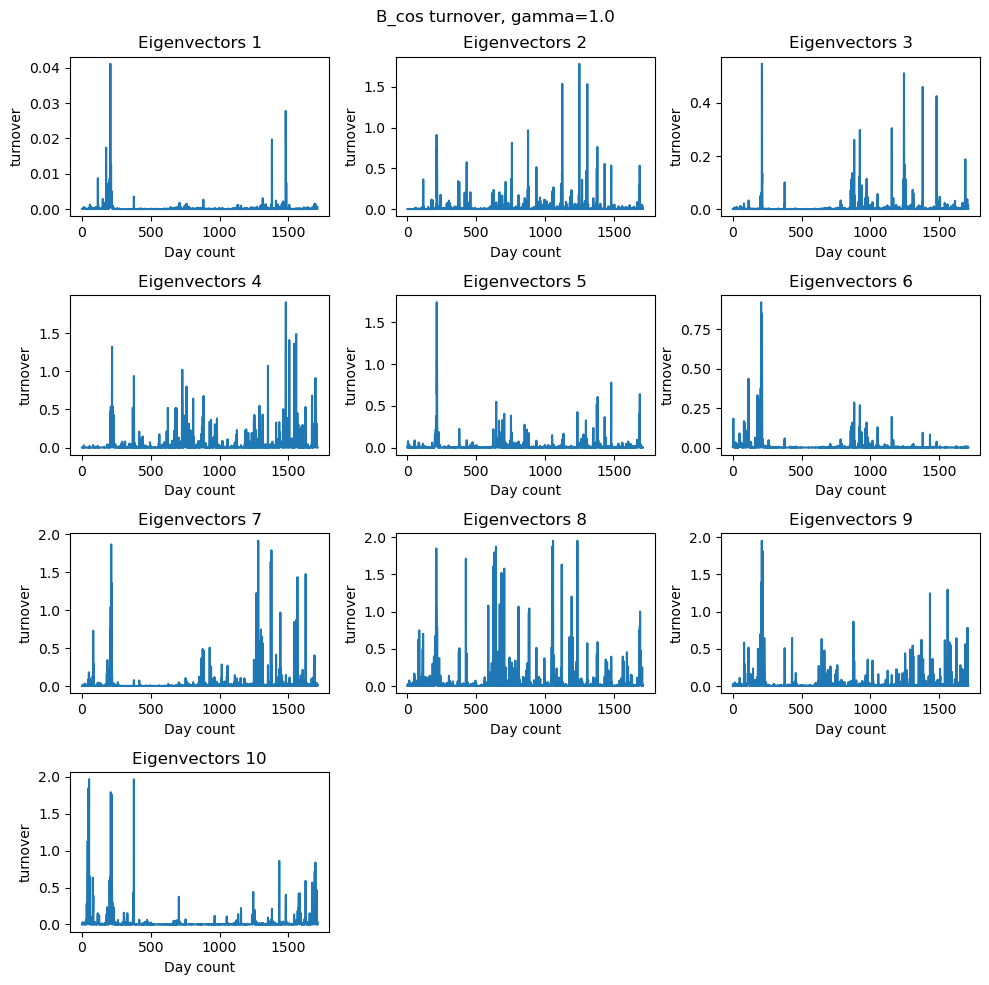

In [25]:
for metric, factor_turnovers in [list(turnovers.items())[-1]]:
    df_plot = pd.DataFrame(factor_turnovers)
    fig, ax = plt.subplots(4, 3, figsize=[10, 10])
    plt.suptitle(f"{metric} turnover, gamma={GAMMA}")
    for k in range(N_FACTORS):
        i, j = k // 3, k % 3
        factor = f"Eigenvectors {k + 1}"
        ax[i, j].set_title(factor)
        ax[i, j].set_xlabel("Day count")
        ax[i, j].set_ylabel("turnover")
        ax[i, j].plot(df_plot[factor])
    for k in range(N_FACTORS, 12):
        ax[k // 3, k % 3].axis("off")
    plt.tight_layout()
    plt.show()


## Optional Save

In [26]:
if SAVE_OUTPUTS:
    suffix = str(GAMMA)[:1]
    characteristics.to_parquet(f"{OUTPUT_DIR}/characteristics_gamma_{suffix}.parquet")
    residuals.to_parquet(f"{OUTPUT_DIR}/residuals_gamma_{suffix}.parquet")
    factors.to_parquet(f"{OUTPUT_DIR}/factors_gamma_{suffix}.parquet")
